# Notebook 06: Knowledge Discovery

> **KDD Step 6**: Interpretation / Knowledge
>
> Rút tri thức từ Decision Tree — KHÔNG chỉ báo cáo metric.
> Tri thức cần đạt 4 tiêu chí: **Valid, Novel, Useful, Understandable**.

In [1]:
import os, sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

from src.tree import DecisionTreeClassifier as ScratchDT

REPORT_DIR = "report"
os.makedirs(REPORT_DIR, exist_ok=True)

## 1. Load Data + Models

In [2]:
with open("data/processed_data.pkl", "rb") as f:
    data = pickle.load(f)
with open("data/results_scratch.pkl", "rb") as f:
    res_scratch = pickle.load(f)

df = pd.read_csv("data/bank-additional/bank-additional-full.csv", sep=";")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dataset: {len(df):,} rows")

Dataset: 41,176 rows


## 2. Feature Importance — So sánh Scenario A vs B

> Duration chiếm importance lớn trong Scenario A.
> Khi loại bỏ (Scenario B), các features thực tế nổi lên.

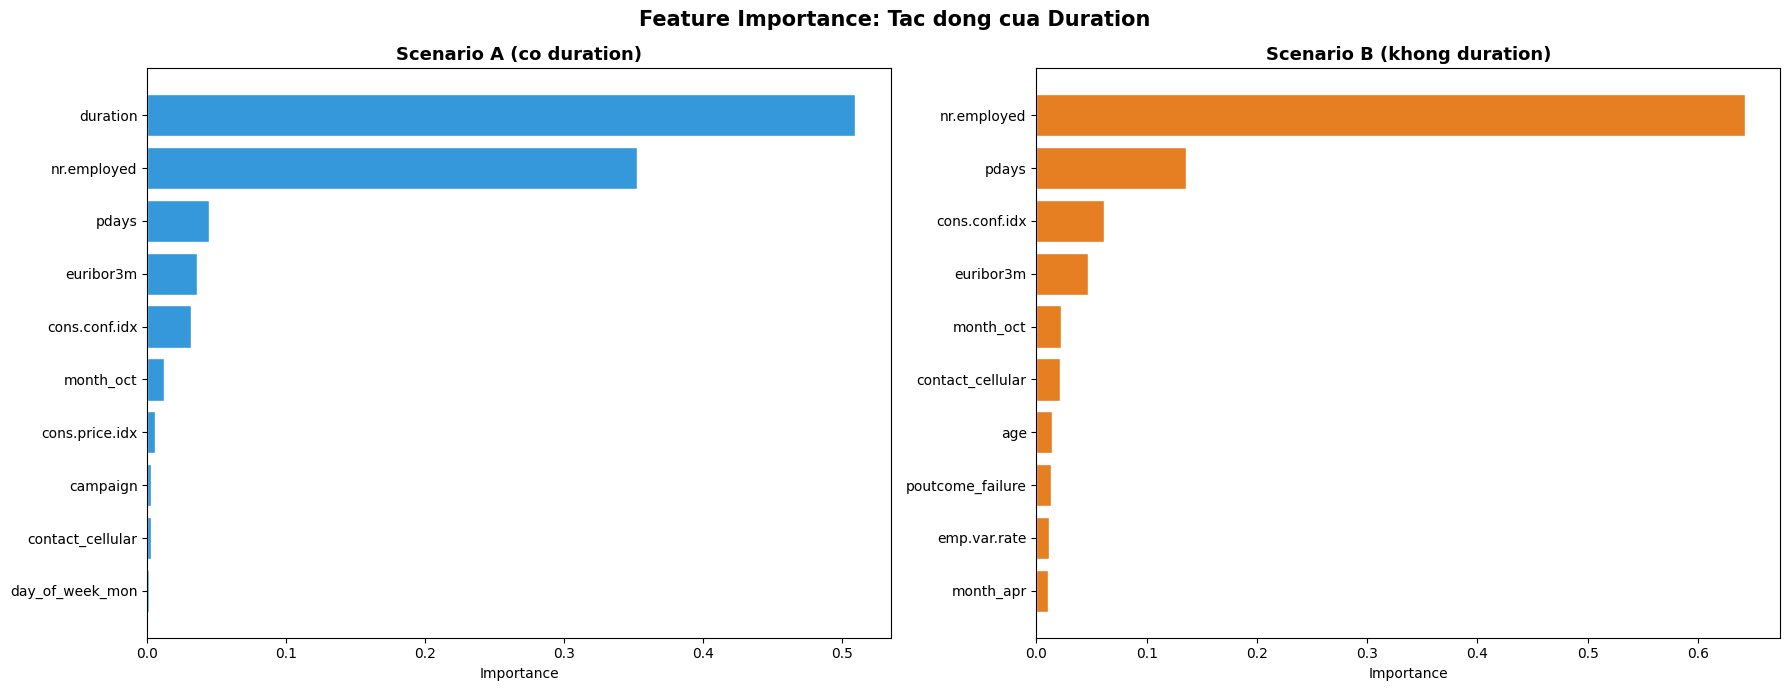

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, scenario, title, color in zip(
    axes,
    ["scenario_A", "scenario_B"],
    ["Scenario A (co duration)", "Scenario B (khong duration)"],
    ["#3498db", "#e67e22"]
):
    imp = res_scratch[scenario]["feature_importance"]
    names = res_scratch[scenario]["feature_names"]
    idx = np.argsort(imp)[::-1][:10]
    ax.barh(range(len(idx)), imp[idx][::-1], color=color, edgecolor="white")
    ax.set_yticks(range(len(idx)))
    ax.set_yticklabels([names[i] for i in idx][::-1])
    ax.set_xlabel("Importance")
    ax.set_title(title, fontweight="bold", fontsize=13)

plt.suptitle("Feature Importance: Tac dong cua Duration", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/06_importance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Decision Rules tu cay

In [4]:
d_B = data["scenario_B"]
dt = ScratchDT(criterion="gini", max_depth=5)
dt.fit(d_B["X_train"], d_B["y_train"], feature_names=d_B["feature_names"])

def extract_rules(node, path=None, rules=None):
    if path is None: path = []
    if rules is None: rules = []
    if node.is_leaf:
        if node.prediction == "yes":
            n_yes = node.class_distribution.get("yes", 0)
            n_total = node.num_samples
            confidence = n_yes / n_total if n_total > 0 else 0
            rules.append({
                "conditions": list(path),
                "prediction": "yes",
                "confidence": confidence,
                "support": n_total,
            })
        return rules
    if node.is_categorical:
        cond = f"{node.feature_name} in {node.categories_left}"
        cond_neg = f"{node.feature_name} not in {node.categories_left}"
    else:
        cond = f"{node.feature_name} <= {node.threshold:.2f}"
        cond_neg = f"{node.feature_name} > {node.threshold:.2f}"
    extract_rules(node.left, path + [cond], rules)
    extract_rules(node.right, path + [cond_neg], rules)
    return rules

rules = extract_rules(dt.root)
rules_sorted = sorted(rules, key=lambda r: r["support"] * r["confidence"], reverse=True)

print("=" * 80)
print("  TOP DECISION RULES -> y = yes (Scenario B)")
print("=" * 80)
for i, rule in enumerate(rules_sorted[:8]):
    print(f"\nRule {i+1} (confidence={rule['confidence']:.2%}, support={rule['support']})")
    for cond in rule["conditions"]:
        print(f"    IF {cond}")
    print(f"    -> THEN y = yes")

  TOP DECISION RULES -> y = yes (Scenario B)

Rule 1 (confidence=78.62%, support=608)
    IF nr.employed <= 5087.65
    IF pdays <= 16.50
    IF day_of_week_mon <= 0.50
    IF nr.employed <= 5049.85
    IF campaign <= 4.50
    -> THEN y = yes

Rule 2 (confidence=54.73%, support=497)
    IF nr.employed <= 5087.65
    IF pdays > 16.50
    IF contact_cellular > 0.50
    IF emp.var.rate > -2.35
    IF poutcome_failure <= 0.50
    -> THEN y = yes

Rule 3 (confidence=61.54%, support=143)
    IF nr.employed <= 5087.65
    IF pdays <= 16.50
    IF day_of_week_mon <= 0.50
    IF nr.employed > 5049.85
    IF age > 21.50
    -> THEN y = yes

Rule 4 (confidence=68.10%, support=116)
    IF nr.employed <= 5087.65
    IF pdays <= 16.50
    IF day_of_week_mon > 0.50
    IF marital_single <= 0.50
    IF cons.conf.idx <= -28.35
    -> THEN y = yes

Rule 5 (confidence=50.67%, support=75)
    IF nr.employed <= 5087.65
    IF pdays <= 16.50
    IF day_of_week_mon > 0.50
    IF marital_single > 0.50
    IF 

## 4. Customer Segmentation

> Chi bao cao segment co **support >= 1%**.

In [5]:
baseline_rate = (df["y"] == "yes").mean()
print(f"Baseline yes-rate: {baseline_rate:.2%}\n")

segments = df.groupby(["job", "education"]).agg(
    total=("y", "count"),
    n_yes=("y", lambda x: (x == "yes").sum()),
).reset_index()
segments["yes_rate"] = segments["n_yes"] / segments["total"]
segments["support_pct"] = segments["total"] / len(df) * 100
segments["lift"] = segments["yes_rate"] / baseline_rate

seg_filtered = segments[segments["support_pct"] >= 1.0].copy()
seg_top = seg_filtered.sort_values("lift", ascending=False).head(10)

print("=" * 85)
print("  TOP SEGMENTS: job x education (support >= 1%)")
print("=" * 85)
print(f"{'Job':<20s} {'Education':<20s} {'Total':>7s} {'Yes':>5s} {'Rate':>8s} {'Lift':>6s} {'Supp%':>6s}")
print("-" * 85)
for _, row in seg_top.iterrows():
    print(f"{row['job']:<20s} {row['education']:<20s} {row['total']:>7d} {row['n_yes']:>5d} "
          f"{row['yes_rate']:>8.2%} {row['lift']:>6.2f} {row['support_pct']:>5.1f}%")

Baseline yes-rate: 11.27%

  TOP SEGMENTS: job x education (support >= 1%)
Job                  Education              Total   Yes     Rate   Lift  Supp%
-------------------------------------------------------------------------------------
retired              basic.4y                 597   185   30.99%   2.75   1.4%
admin.               university.degree       5750   822   14.30%   1.27  14.0%
self-employed        university.degree        765    96   12.55%   1.11   1.9%
management           university.degree       2063   257   12.46%   1.11   5.0%
technician           university.degree       1809   225   12.44%   1.10   4.4%
admin.               high.school             3329   382   11.47%   1.02   8.1%
entrepreneur         university.degree        610    66   10.82%   0.96   1.5%
housemaid            basic.4y                 474    51   10.76%   0.96   1.2%
blue-collar          high.school              878    94   10.71%   0.95   2.1%
technician           professional.course     3317

### 4.1 Heatmap

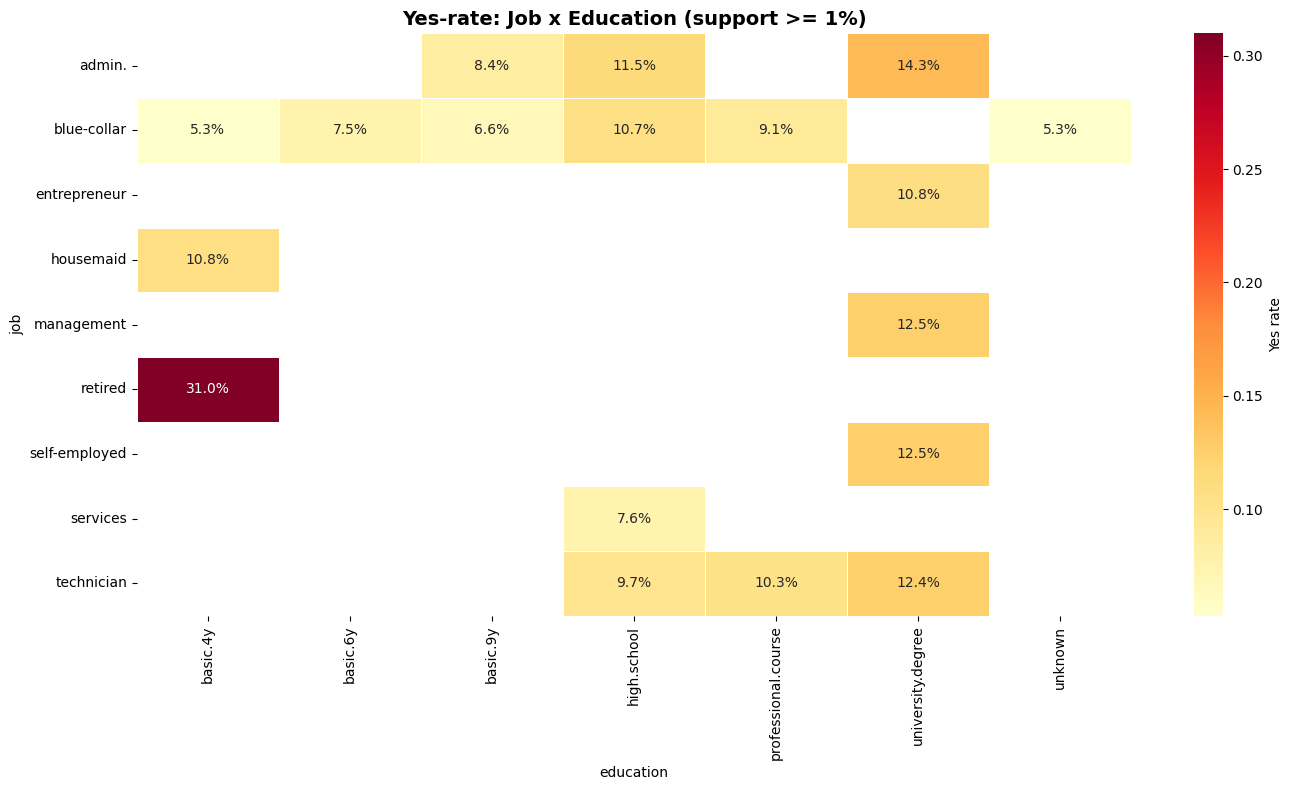

In [6]:
pivot = seg_filtered.pivot_table(index="job", columns="education",
                                 values="yes_rate", aggfunc="mean")

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar_kws={"label": "Yes rate"})
ax.set_title("Yes-rate: Job x Education (support >= 1%)",
             fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/06_segment_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.2 Segment theo Month x Contact

In [7]:
seg_mc = df.groupby(["month", "contact"]).agg(
    total=("y", "count"),
    n_yes=("y", lambda x: (x == "yes").sum()),
).reset_index()
seg_mc["yes_rate"] = seg_mc["n_yes"] / seg_mc["total"]
seg_mc["support_pct"] = seg_mc["total"] / len(df) * 100
seg_mc["lift"] = seg_mc["yes_rate"] / baseline_rate

seg_mc_f = seg_mc[seg_mc["support_pct"] >= 1.0].sort_values("lift", ascending=False)

print("TOP SEGMENTS: month x contact (support >= 1%):")
print(f"{'Month':<10s} {'Contact':<12s} {'Total':>7s} {'Yes':>5s} {'Rate':>8s} {'Lift':>6s}")
print("-" * 55)
for _, row in seg_mc_f.head(10).iterrows():
    print(f"{row['month']:<10s} {row['contact']:<12s} {row['total']:>7d} {row['n_yes']:>5d} "
          f"{row['yes_rate']:>8.2%} {row['lift']:>6.2f}")

TOP SEGMENTS: month x contact (support >= 1%):
Month      Contact        Total   Yes     Rate   Lift
-------------------------------------------------------
mar        cellular         486   252   51.85%   4.60
sep        cellular         482   238   49.38%   4.38
oct        cellular         563   253   44.94%   3.99
jun        cellular         820   349   42.56%   3.78
apr        cellular        2444   493   20.17%   1.79
nov        telephone        425    50   11.76%   1.04
may        cellular        5517   614   11.13%   0.99
aug        cellular        5907   619   10.48%   0.93
nov        cellular        3675   366    9.96%   0.88
jul        cellular        6092   590    9.68%   0.86


## 5. Duration Impact Analysis

In [8]:
print("=" * 70)
print("  DURATION IMPACT")
print("=" * 70)

print("\nTop 5 Features - Scenario A:")
imp_A = res_scratch["scenario_A"]["feature_importance"]
names_A = res_scratch["scenario_A"]["feature_names"]
for i in np.argsort(imp_A)[::-1][:5]:
    print(f"  {names_A[i]}: {imp_A[i]:.4f}")

print("\nTop 5 Features - Scenario B:")
imp_B = res_scratch["scenario_B"]["feature_importance"]
names_B = res_scratch["scenario_B"]["feature_names"]
for i in np.argsort(imp_B)[::-1][:5]:
    print(f"  {names_B[i]}: {imp_B[i]:.4f}")

print("\nPHAN TICH:")
print("  - Duration khong phu hop cho du doan truoc chien dich")
print("  - Duration co gia tri cho phan tich hau nghiem")
print("  - Khi loai duration, chi so kinh te vi mo va lich su tiep thi noi len")

  DURATION IMPACT

Top 5 Features - Scenario A:
  duration: 0.5094
  nr.employed: 0.3525
  pdays: 0.0445
  euribor3m: 0.0357
  cons.conf.idx: 0.0318

Top 5 Features - Scenario B:
  nr.employed: 0.6422
  pdays: 0.1359
  cons.conf.idx: 0.0611
  euribor3m: 0.0468
  month_oct: 0.0222

PHAN TICH:
  - Duration khong phu hop cho du doan truoc chien dich
  - Duration co gia tri cho phan tich hau nghiem
  - Khi loai duration, chi so kinh te vi mo va lich su tiep thi noi len


## 6. Ket luan + Khuyen nghi

> Ket luan **trung thuc, co dieu kien**, khong noi qua.

In [9]:
print("=" * 70)
print("  KET LUAN TONG HOP")
print("=" * 70)
print()
print("1. VE THUAT TOAN:")
print("   - DT from scratch cho ket qua gan tuong duong sklearn")
print("   - Sai khac nho (neu co): tie-breaking, threshold, implementation")
print("   - Gini max_depth=5: can bang accuracy va interpretability")
print()
print("2. VE DU LIEU:")
print("   - Duration tang metric nhung prediction-time unavailable")
print("   - Class imbalance (89:11): accuracy don thuan khong du")
print("   - Metric phu hop: F1, Recall cho class yes")
print()
print("3. KHUYEN NGHI (pattern quan sat, KHONG phai nhan qua):")
print("   - poutcome=success co ty le dang ky cao -> uu tien goi lai")
print("   - Ty le khac nhau theo thang: can kiem chung them")
print("   - Correlation != causation")
print()
print("4. GIOI HAN:")
print("   - Chi 1 thuat toan (DT)")
print("   - Dataset tu Bo Dao Nha 2008-2010")
print("   - max_depth=5 chon thu cong")
print("   - Unknown values giu nguyen")

  KET LUAN TONG HOP

1. VE THUAT TOAN:
   - DT from scratch cho ket qua gan tuong duong sklearn
   - Sai khac nho (neu co): tie-breaking, threshold, implementation
   - Gini max_depth=5: can bang accuracy va interpretability

2. VE DU LIEU:
   - Duration tang metric nhung prediction-time unavailable
   - Class imbalance (89:11): accuracy don thuan khong du
   - Metric phu hop: F1, Recall cho class yes

3. KHUYEN NGHI (pattern quan sat, KHONG phai nhan qua):
   - poutcome=success co ty le dang ky cao -> uu tien goi lai
   - Ty le khac nhau theo thang: can kiem chung them
   - Correlation != causation

4. GIOI HAN:
   - Chi 1 thuat toan (DT)
   - Dataset tu Bo Dao Nha 2008-2010
   - max_depth=5 chon thu cong
   - Unknown values giu nguyen
